**VERSION v3**: I used a new paradigm where the signal of each satellite has its own alpha value for fitting; I tried to keep the rest of the calculations in the code as close as possible to the original one. This second try uses the new optimization with `nnls` and tries to fit all 286 satellite signals.

### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [5]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation as sim
import natsort
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters as pm


In [7]:
## ----- FITTING PARAMETERS ----- ##
# folder of final results
folder = "results/v3_results/"


In [8]:
pm.show_parameters(plotting=True)
print("")
print(f"Showing results from folder: {folder}")


Block: 1551055211
Frequency range: 1100 - 1350 MHz

Showing results from folder: results/v3_results/


### 2. Set-up of global variables and functions

We start by defining some global variables (like the simulation and some functions) which will be the same for all of the masks. We also define the plotting functions, in order not to repeat code unnecessarily.

In [9]:
# we can use the same object throughout everything, only the mask changes
print("Simulating...")
sat = sim.SatelliteSimulation(
        block=str(pm.block),
        use_data=True,
        path_data=pm.path_data,
        path_beam=pm.path_data,
        survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency],
        path_catalog="Satellite_Catalogue/individual_satellite_constellation_catalog.csv",
        beam_model=pm.beam_model,
        freq_range=[pm.fs, pm.fe],
        freq_slice=[pm.fs_slice, pm.fe_slice],
        time_slice=[None,None],
        include_cons=pm.include_cons,
        verbose=False,
    )
print("Done")

# these values are the same always
fs = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
ts = sat.nd_s0[sat.itime[0]:sat.itime[1]]
N = len(sat.catalog["Alpha"])


Simulating...
Getting catalog...
Getting beam response (2GB) ...
Getting temperature factors for each signal...
Getting observational data...
Done


In [10]:
## ----- PLOTTING FUNCTIONS (except for no mask) ----- ##

def get_results(mask, pars):
    ''' Retrieve alphas from the file. '''

    # storing values
    alphas = {p: [] for p in pars}
    simulations = {p: [] for p in pars}
    CFs = {p: [] for p in pars}
    observations = {}

    for p in pars:
        # creating mask
        pt = p if mask!="deg" else f"{pm.path_data}nearby_satellites/nearby_satellite_close_angle_{p}.p"
        sat.create_mask(**{mask:pt, "apply":False})
        observations[p] = np.ma.masked_equal(sat.observations_sat.T*sat.mask.T,0)
        Npoints = sat.mask[sat.mask].size
    
        for CF in ["C1","C2"]:
            # getting values
            print(f"Getting values for {mask} = {p} and CF = {CF}.")
            #alphasi = pickle.load( open(pm.my_name(folder,CF,deg=p),'rb') )["best-fit"]
            alphasi = pickle.load( open(pm.my_name(**{"folder":folder,"CF":CF,mask:p}), "rb") )["best-fit"]
            sat.execute_withmask(alphasi)
            alphas[p].append(alphasi)
            simulations[p].append(np.ma.masked_equal(sat.simulation.T,0))
            
            # calculating CF
            matrix = sat.observations_sat*sat.mask-sat.simulation
            if CF=="C1":  CFs[p].append(np.sum(matrix/sat.observations)**2 / Npoints)
            else:  CFs[p].append(np.sum(matrix**2 ) / Npoints)
    return alphas, simulations, CFs, observations

# ----------------------------------------------- #

def plot_alphas(alphas, pars_mask, title):
    ''' Creates the plot of alpha values for C1 and C2. '''

    # creating figures
    points = ['o', '*', 'x', '.', 'o']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)

    # plotting values
    xs = np.arange(1, N + 1)
    for i,p in enumerate(pars_mask):
        axs[0].plot(xs, alphas[p][0], points[i], alpha=(1-i/4), label="{}: {}".format(title,p))
        axs[1].plot(xs, alphas[p][1], points[i], alpha=(1-i/4), label="{}: {}".format(title,p))

    # showing figure
    fig.suptitle(r'Block: {} {} Mask'.format(pm.block,title))
    for i,CF in enumerate(["C_1","C_2"]):
        ax = axs[i]
        ax.set_ylabel('Amplitude')
        textstr = r"$\sigma_D={}$".format(CF)
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.axhline(0, color='black', linestyle='--')
        ax.legend()
    axs[1].set_xlabel(r'Signal Position $[\alpha_{i}]$')
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_1d(observations, simulations, CFs, pars_mask, title):
    ''' Creates the plots for 1d comparison between data and simulation. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 3*len(pars_mask)), nrows=len(pars_mask), ncols=2, sharey=True)
    fig.suptitle(r'Block {}, {} Mask'.format(pm.block, title))

    for iCF,CF in enumerate(["C_1","C_2"]):
        for ilabel,label in enumerate(pars_mask):
            
            # plotting values
            ax = axs[ilabel,iCF]
            ax.plot(fs, np.ma.mean(observations[label]+sat.observations_BG.T, axis=0), label='Observation')
            ax.plot(fs, np.ma.mean(simulations[label][iCF]+sat.observations_BG.T, axis=0), '--', label='Simulation')

            # defining figure
            textstr = "$\\sigma_D={}$\n{}={}\nFoM$={:.3f}$".format(CF,title,label,CFs[label][iCF])
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
            if ilabel==1:  ax.set_xlabel('Frequency [MHz]')
            ax.set_ylabel('Temperature [K]')
            ax.legend(loc='upper right')

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------- #

def plot_2d(observations, simulations, pars_mask, title):
    ''' Creates the plots for 2d comparison between data and simulation. ''' 

    # creating figures
    super_titles = ['Observation', r'$C_1$', r'$C_2$']
    fig,axs = plt.subplots(figsize=(16,3+2*len(pars_mask)), nrows=len(pars_mask), ncols=3,
                           sharey=True, sharex=True)
    fig.suptitle("Block {}, {} Mask".format(pm.block, title))

    for ilabel,label in enumerate(pars_mask):
        for idata,data in enumerate([observations[label], simulations[label][0], simulations[label][1]]):
            # plotting values
            ax = axs[ilabel,idata]
            default = observations[label] + sat.observations_BG.T
            cax = ax.imshow(data + sat.observations_BG.T, aspect='auto', extent=[fs[0],fs[-1],ts[-1],ts[0]], 
                            vmax=np.max(default), vmin=np.ma.min(default))
    
            # defining figure
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            ax.set_title(super_titles[idata])
            ax.set_ylabel('Time [sec]')
            ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

### 3. Graphs

#### 3.1 No Masking

We want to check the signals in each constellation and see the differences between satellites, to check if they are true amplitudes or if it's just noise that overfitted.

In [70]:
def plot_alphas_by_constellation_nomask(alphas, CF):
    ''' Plot alpha results divided by constellation and discretized by signal, for a given CF. '''

    # creating figures
    nCF = 0 if CF=="C1" else 1

    ncolors = 0
    for i in range(len(sat.sats)):
        # setting up the figure
        if i==0 or sat.cons[i]!=sat.cons[i-1]:
            fig, ax = plt.subplots(figsize=(12, 6))
            cm = plt.cm.viridis(np.linspace(0, 1, sat.cons.count(sat.cons[i])))
            icolors = i
        
        # getting values and plotting
        xs = np.arange(1, sat.n_signals[i] + 1)
        ys = alphas[nCF][sat.index_sats[i]: sat.index_sats[i]+sat.n_signals[i]]

        # creating a label if the values are high enough
        if np.any(ys > 1.5):  ax.plot(xs, ys, "o", color=cm[i-icolors], label=sat.sats[i])
        else:  ax.plot(xs, ys, "o", color=cm[i-icolors])

        # plotting the map
        if i==len(sat.sats)-1 or sat.cons[i]!=sat.cons[i+1]:  
            ax.set_ylabel('Amplitude')
            ax.set_xlabel(r'Signal $[\alpha_{i}]$')
            textstr = f"Cons: {sat.cons[i]}"
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
            ax.axhline(0, color='black', linestyle='--')
            ax.legend()

    # showing figure
    fig.suptitle(f'Alphas: no mask, CF={CF}')
    fig.tight_layout()
    fig.show()
    

In [14]:
# storing values
alphas = []
simulations = []
CFs = []

for CF in ["C1","C2"]:
    # getting values
    print("Getting values for no mask and CF = {}.".format(CF))
    alphasi = pickle.load( open(pm.my_name(folder,CF),'rb') )["best-fit"]
    sat.execute(alphasi)

    # saving values
    alphas.append(alphasi)
    simulations.append(np.ma.masked_equal(sat.simulation.T,0))
    if CF=="C1":  
        CFs.append(np.sum(((sat.observations_sat-sat.simulation)/sat.observations)**2) / simulations[-1].size)
    elif CF=="C2":  
        CFs.append(np.sum((sat.observations_sat-sat.simulation)**2) / simulations[-1].size)
    

Getting values for no mask and CF = C1.
Getting values for no mask and CF = C2.


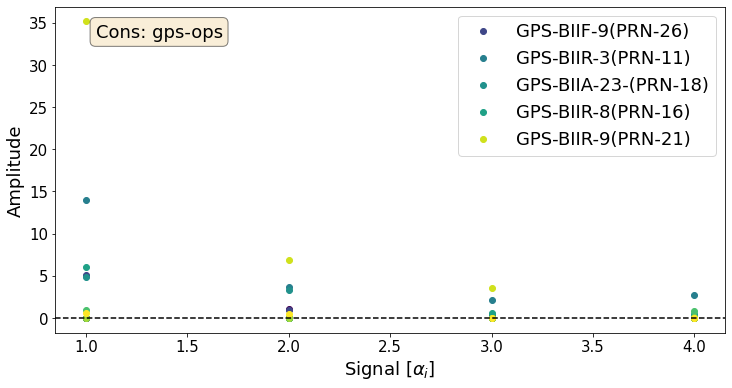

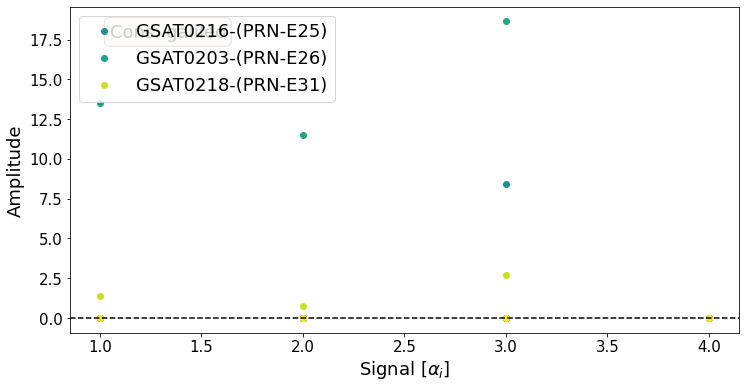

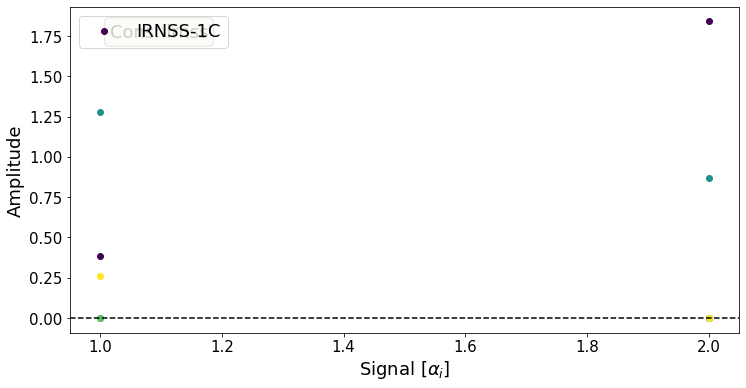

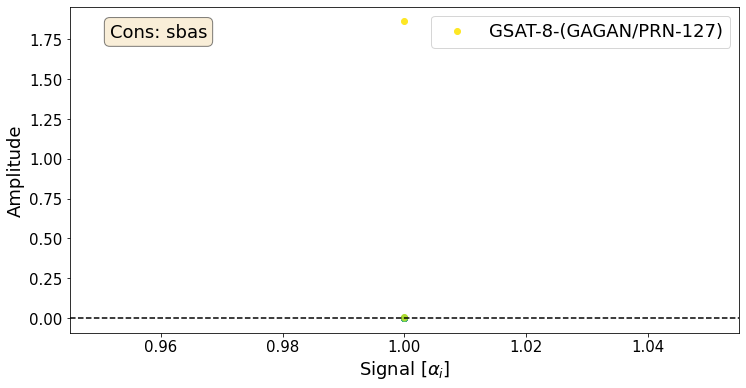

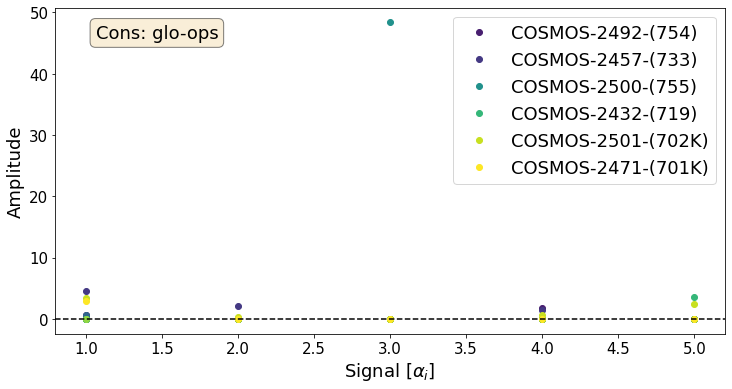

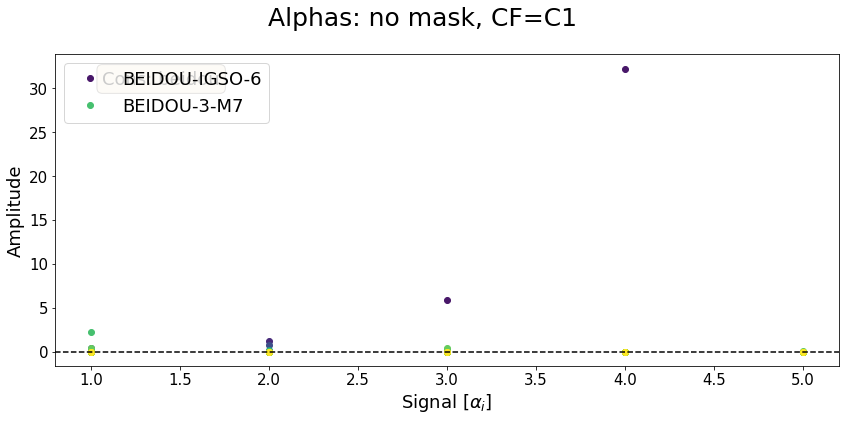

In [71]:
plot_alphas_by_constellation_nomask(alphas,CF="C1")

No handles with labels found to put in legend.


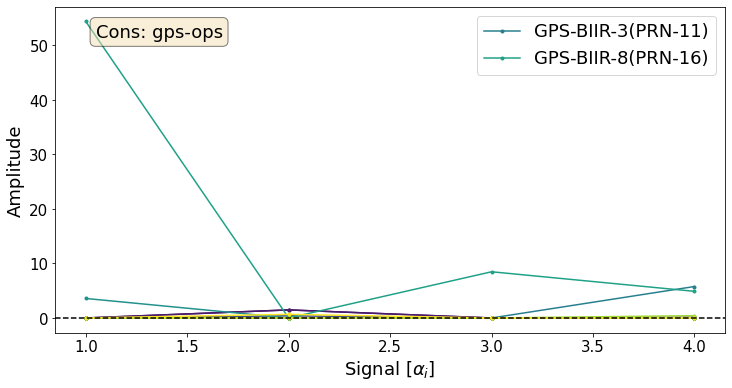

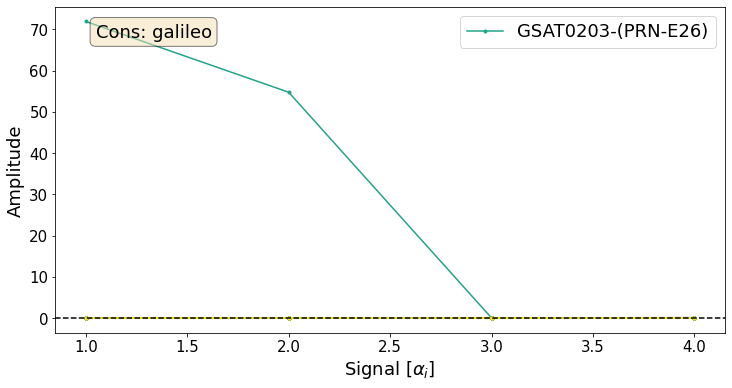

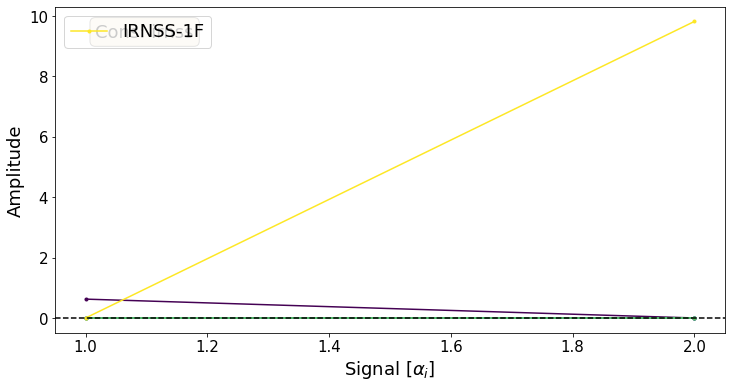

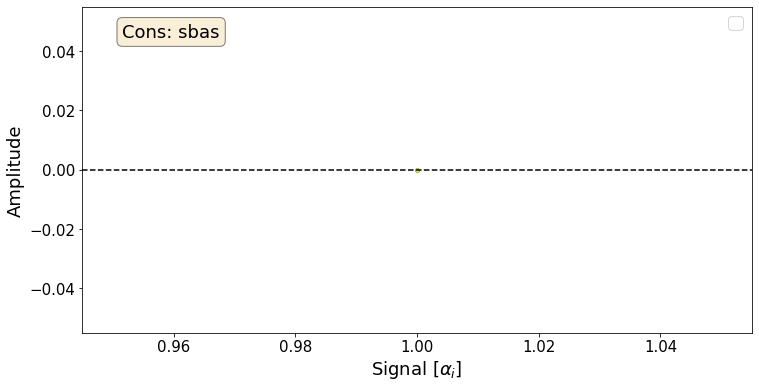

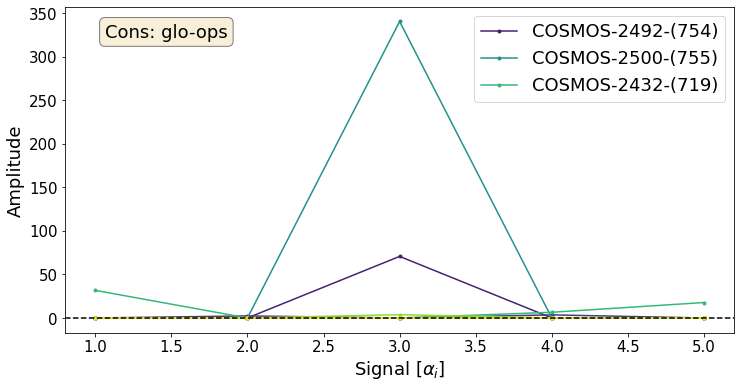

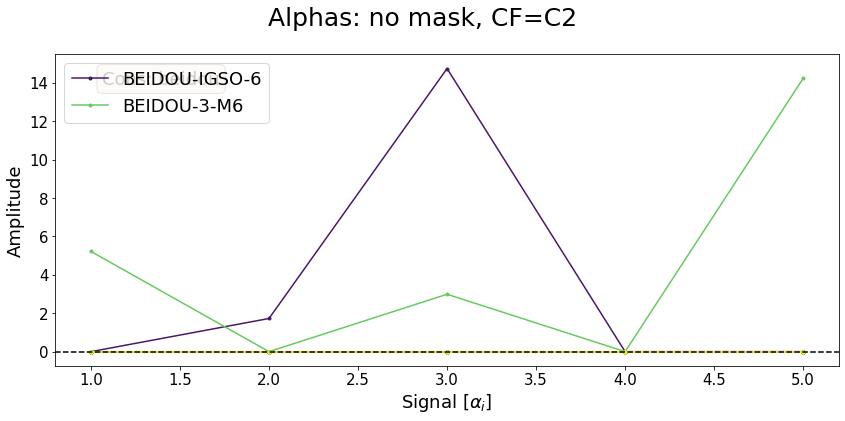

In [61]:
plot_alphas_by_constellation_nomask(alphas,CF="C2")